# Analyzing the difference between geodesic and tangent PCA

In [1]:
import os
import sys
from pathlib import Path
sys.path.append(str(Path(os.getcwd()).parent.absolute()))

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from numpy.linalg import norm
from pca.bures_wasserstein_principal_geodesic_analysis import BuresWassersteinPGA, BuresWassersteinTPCA
#from pca.bures_wasserstein_tangent_pca import BuresWassersteinTPCA
from tools.compute import align, project, make_rotation_2d
from tools.generate import generate_spd_matrices_on_intersecting_geodesics
from scipy.linalg import sqrtm, det

INFO: Using numpy backend


We randomly generate two intersecting geodesics in the space of SPD matrices for the Bures-Wasserstein metric, and sample `n_times` points on these geodesics between `-time` and `time`. We then perform geodesic and tangent pca on these SPD matrices and compare the results in terms of costs (sum of squared residuals on each component). While in tangent PCA, the principal components intersect at the Fréchet mean by construction, this is no longer true for geodesic PCA. Therefore we also compare the intersection of the principal components for each method. We iterate this procedure `n_iter` times in order to get an overview of the different behaviors of the two methods.

In [3]:
dim = 2
time = 1
n_times = 10
n_iter = 100

In [4]:
def angle_from_point(point, sq_root):
    rotation = np.linalg.inv(sq_root) @ point
    assert np.abs(det(rotation) - 1) < 1e-6
    return np.arccos(rotation[0, 0])

def angles_from_points(points, sq_roots):
    if points.ndim == 3:
        return np.array([angle_from_point(pt, sqt) for (pt, sqt) in zip(points, sq_roots)])
    return angle_from_point(points, sq_roots)

def initialize(points_spd, mean):
    mean_init = sqrtm(mean)
    points_init = align(points_spd, mean_init)
    sq_roots = np.stack([sqrtm(pt_spd) for pt_spd in points_spd])
    angles_init = angles_from_points(points_init, sq_roots)
    return mean_init, angles_init

In [5]:
np.random.seed(1)

points_spd = np.zeros((n_iter, 2 * n_times, 2, 2))
sec_curvature = np.zeros(n_iter)
ric_curvature = np.zeros((n_iter, 2 * (n_times - 1)))
res_tpca_list = []
res_gpca_list = []

for i in range(n_iter):
    if i%10 == 0: print(i, end=" ")
    pts_spd, mean, sec_curv, ric_curv = generate_spd_matrices_on_intersecting_geodesics(dim=dim, n_times=n_times, time=time)

    res_tpca = BuresWassersteinTPCA.fit(pts_spd)
    mean_init, angles_init = initialize(pts_spd, mean)
    res_gpca = BuresWassersteinPGA(dim=2, mean_init=mean_init, angles_init=angles_init).fit(pts_spd)
    
    res_tpca_list.append(res_tpca)
    res_gpca_list.append(res_gpca)
    points_spd[i] = pts_spd
    sec_curvature[i] = sec_curv
    ric_curvature[i] = ric_curv


0 10 20 30 40 50 60 70 80 Warning: max number of iterations reached for component 3.
90 

In [6]:
status_gpca = np.array([res_gpca_list[i]['status'] for i in range(n_iter)])
costs_gpca = np.stack([res_gpca_list[i]['costs'] for i in range(n_iter)])
costs_tpca = np.stack([res_tpca_list[i]['costs'] for i in range(n_iter)])
mean_gpca = np.stack([res_gpca_list[i]['mean_spd'] for i in range(n_iter)])
mean_tpca = np.stack([res_tpca_list[i]['mean_spd'] for i in range(n_iter)])
var_gpca = np.stack([res_gpca_list[i]['variances'] for i in range(n_iter)])
var_tpca = np.stack([res_tpca_list[i]['variances'] for i in range(n_iter)])

### Count and remove failures

In [27]:
mask_success = (status_gpca != 0)
print(status_gpca)

[0 1 1 1 1 1 1 2 1 0 1 1 1 1 1 0 0 0 0 1 1 1 0 1 1 1 1 0 1 0 1 1 1 1 1 1 1
 1 1 1 1 0 1 0 1 0 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1
 1 0 1 1 1 1 1 1 1 1 0 1 0 0 1 1 0 1 1 1 0 1 1 1 1 2]


In [28]:
n_success = np.sum(mask_success)
print('Success rate is ', np.around(n_success / n_iter * 100, 2), '%')

Success rate is  79.0 %


### Compare costs between PGA and TPCA

In [29]:
costs_ratios = (costs_tpca[:, :3] - costs_gpca) / costs_tpca[:, :3]

In [30]:
def analyse_costs_ratios(costs_ratios):
    # no significant change
    mask_1 = (np.abs(costs_ratios[:, 0]) < 0.01) * (np.abs(costs_ratios[:, 1]) < 0.01) * (np.abs(costs_ratios[:, 2]) < 0.01) 
    # deterioration
    mask_2 = (costs_ratios[:, 0] < -0.01) + (costs_ratios[:, 1] < -0.01) + (costs_ratios[:, 2] < -0.01)   
    # improvement
    mask_3 = (
        (costs_ratios[:, 0] > 0.01) * (costs_ratios[:, 1] > -0.01) * (costs_ratios[:, 2] > -0.01) + 
        (costs_ratios[:, 0] > -0.01) * (costs_ratios[:, 1] > 0.01) * (costs_ratios[:, 2] > -0.01) + 
        (costs_ratios[:, 0] > -0.01) * (costs_ratios[:, 1] > -0.01) * (costs_ratios[:, 2] > 0.01) 
    )  
    print(f'Less than 1% change in {np.around(np.sum(mask_1) / len(costs_ratios) * 100)}% cases')
    print(f'More than 1% deterioration in {np.around(np.sum(mask_2) / len(costs_ratios) * 100)}% cases')
    print(f'More than 1% improvement in {np.around(np.sum(mask_3) / len(costs_ratios) * 100)}% cases')
    return mask_1, mask_2, mask_3

In [31]:
print('All status:')
_ = analyse_costs_ratios(costs_ratios)

All status:
Less than 1% change in 67.0% cases
More than 1% deterioration in 3.0% cases
More than 1% improvement in 30.0% cases


In [32]:
print('Status = success:')
_ = analyse_costs_ratios(costs_ratios[mask_success])

Status = success:
Less than 1% change in 82.0% cases
More than 1% deterioration in 0.0% cases
More than 1% improvement in 18.0% cases


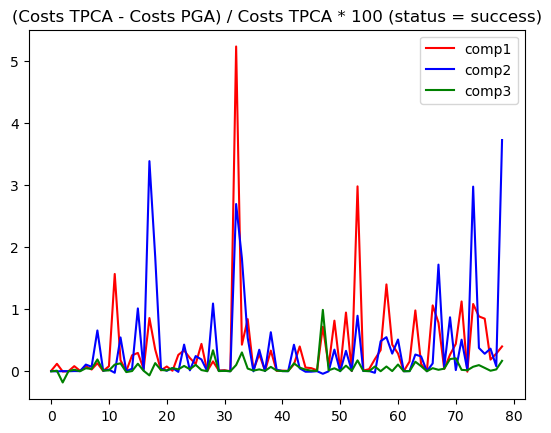

In [33]:
plt.plot(np.arange(n_success), costs_ratios[mask_success, 0] * 100, 'r', label='comp1')
plt.plot(np.arange(n_success), costs_ratios[mask_success, 1] * 100, 'b', label='comp2')
plt.plot(np.arange(n_success), costs_ratios[mask_success, 2] * 100, 'g', label='comp3')
plt.title('(Costs TPCA - Costs PGA) / Costs TPCA * 100 (status = success)')
plt.legend()
plt.show()

### Compare variances between PGA and TPCA

In [34]:
var_diff = var_gpca - var_tpca[:, :3]
var_perc_gpca = np.einsum('ij,i->ij', var_gpca, 1 / np.sum(var_gpca, axis=1)) * 100
var_perc_tpca = np.einsum('ij,i->ij', var_tpca, 1 / np.sum(var_tpca, axis=1)) * 100
var_perc_diff = var_perc_gpca - var_perc_tpca[:, :3]

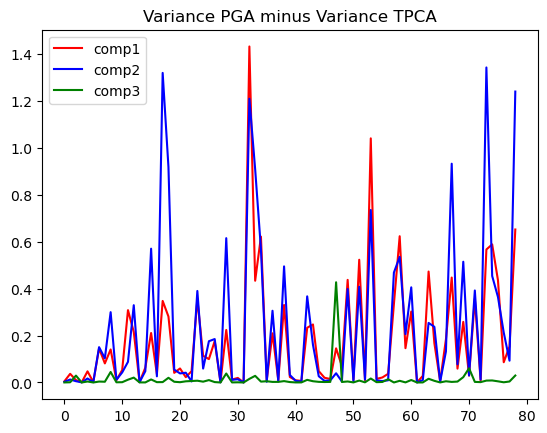

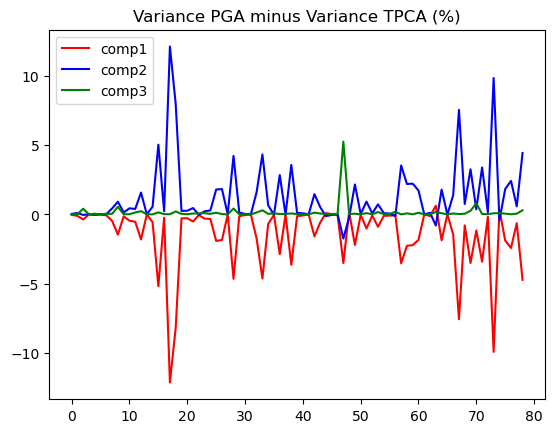

In [35]:
plt.plot(np.arange(n_success), var_diff[mask_success, 0], 'r', label='comp1')
plt.plot(np.arange(n_success), var_diff[mask_success, 1], 'b', label='comp2')
plt.plot(np.arange(n_success), var_diff[mask_success, 2], 'g', label='comp3')
plt.title('Variance PGA minus Variance TPCA')
plt.legend()
plt.show()
plt.plot(np.arange(n_success), var_perc_diff[mask_success, 0], 'r', label='comp1')
plt.plot(np.arange(n_success), var_perc_diff[mask_success, 1], 'b', label='comp2')
plt.plot(np.arange(n_success), var_perc_diff[mask_success, 2], 'g', label='comp3')
plt.title('Variance PGA minus Variance TPCA (%)')
plt.legend()
plt.show()

In PGA, the variance increases, compared to TPCA, for each component simultaneaously, which is possible because the sum of the components variances is not constant, unlike in the Euclidean case, where it is always equal to the data total variance. When we look at the percentage of variance for each component, we see that it decreases for the first component while it increases for the others. For the percentage of variance of the first component to increase, the absolute value of the variance would need to increase more for component 1 than for the others, which is not the case here.

### Relate costs to curvature

We try to relate the difference of performance of PGA and TPCA to curvature. We choose two measures of curvature:
- the sectional curvature of the plane at the intersection of the 2 geodesics, generated by the initial tangent vectors of the geodesics
- the mean Ricci curvature along both geodesics

In [40]:
ricci_mean = np.mean(ric_curvature, axis=1)
mean_ratios = np.array([norm(mean_tpca[i] - mean_gpca[i]) / norm(mean_tpca[i]) for i in range(n_iter)])

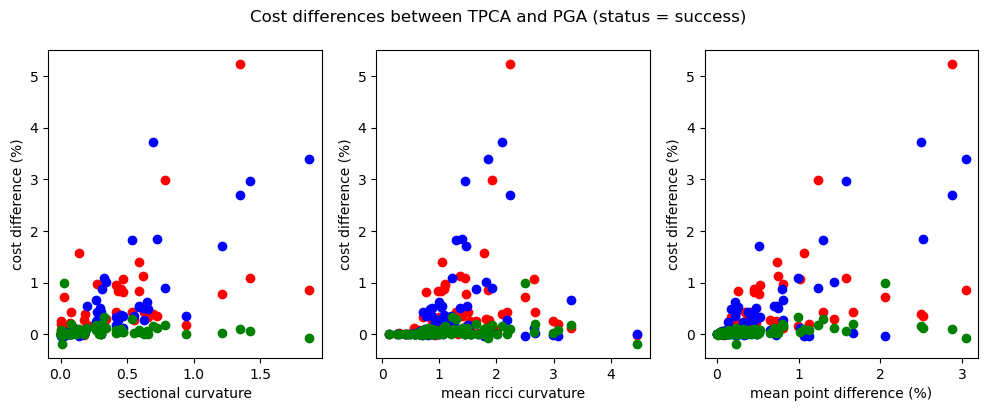

In [44]:
fig = plt.figure(figsize=(12, 4))
fig.add_subplot(131)
plt.plot(sec_curvature[mask_success], costs_ratios[:, 0][mask_success] * 100, 'or')
plt.plot(sec_curvature[mask_success], costs_ratios[:, 1][mask_success] * 100, 'ob')
plt.plot(sec_curvature[mask_success], costs_ratios[:, 2][mask_success] * 100, 'og')
plt.xlabel('sectional curvature')
plt.ylabel('cost difference (%)')

fig.add_subplot(132)
plt.plot(ricci_mean[mask_success], costs_ratios[:, 0][mask_success] * 100, 'or')
plt.plot(ricci_mean[mask_success], costs_ratios[:, 1][mask_success] * 100, 'ob')
plt.plot(ricci_mean[mask_success], costs_ratios[:, 2][mask_success] * 100, 'og')
plt.xlabel('mean ricci curvature')
plt.ylabel('cost difference (%)')

fig.add_subplot(133)
plt.plot(mean_ratios[mask_success] * 100, costs_ratios[:, 0][mask_success] * 100, 'or')
plt.plot(mean_ratios[mask_success] * 100, costs_ratios[:, 1][mask_success] * 100, 'ob')
plt.plot(mean_ratios[mask_success] * 100, costs_ratios[:, 2][mask_success] * 100, 'og')
plt.xlabel('mean point difference (%)')
plt.ylabel('cost difference (%)')
plt.suptitle('Cost differences between TPCA and PGA (status = success)')
plt.show()

### Visualize failing example

In [61]:
i = np.argmax(costs_ratios[:, 1])
print('experiment number ', i)
print('status is: ', status_gpca[i])
print('message is: ', res_gpca_list[i]['message'])

experiment number  27
status is:  0
message is:  fail: at least one component line leaves the space of invertible matrices


In [54]:
print('Variances des projections')
print('GPCA: ', np.around(var_gpca[i], 2), np.around(np.sum(var_gpca[i]), 2))
print('TPCA: ', np.around(var_tpca[i], 2), np.around(np.sum(var_tpca[i]), 2))

Variances des projections
GPCA:  [15.33 11.84  6.41] 33.58
TPCA:  [6.47 0.72 0.01 0.  ] 7.2


In [55]:
print('Variances des projections (%)')
print('GPCA: ', np.around(var_gpca[i] / np.sum(var_gpca[i]), 2), np.around(np.sum(var_gpca[i]), 2))
print('TPCA: ', np.around(var_tpca[i] / np.sum(var_tpca[i]), 2), np.around(np.sum(var_tpca[i]), 2))

Variances des projections (%)
GPCA:  [0.46 0.35 0.19] 33.58
TPCA:  [0.9 0.1 0.  0. ] 7.2


In [56]:
print('Variance des résidus')
print('GPCA: ', np.around(costs_gpca[i], 2), np.around(np.sum(costs_gpca[i]), 2))
print('TPCA: ', np.around(costs_tpca[i, :3], 2), np.around(np.sum(costs_tpca[i, :3]), 2))

Variance des résidus
GPCA:  [ 0.59  2.29 12.79] 15.68
TPCA:  [0.6  6.4  7.26] 14.27


In [57]:
print('Variance des résidus (%)')
print('GPCA: ', np.around(costs_gpca[i] / np.sum(costs_gpca[i]), 2), np.around(np.sum(costs_gpca[i]), 2))
print('TPCA: ', np.around(costs_tpca[i, :3] / np.sum(costs_tpca[i, :3]), 2), np.around(np.sum(costs_tpca[i, :3]), 2))

Variance des résidus (%)
GPCA:  [0.04 0.15 0.82] 15.68
TPCA:  [0.04 0.45 0.51] 14.27


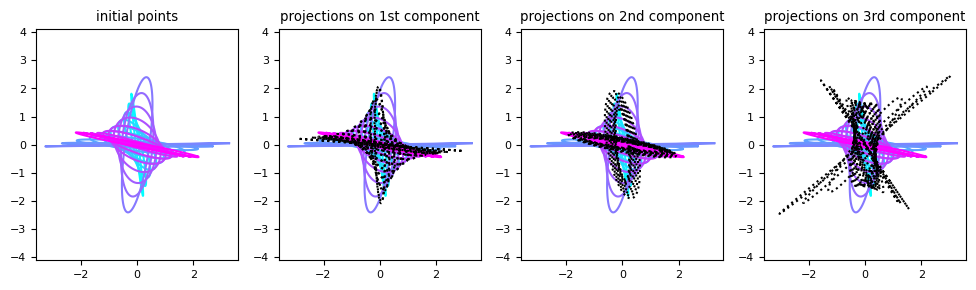

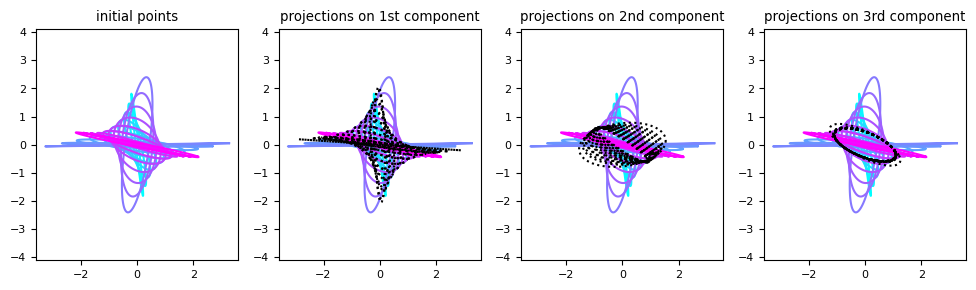

In [59]:
from tools.plot_2d import plot_results
plot_results(points_spd[i], res_gpca_list[i])
plot_results(points_spd[i], res_tpca_list[i])

### Visualize successful example

In [64]:
i = np.where(costs_ratios[:, 1] == np.max(costs_ratios[mask_success, 1]))[0][0]
print('experiment number ', i)
print('status is: ', status_gpca[i])
print('message is: ', res_gpca_list[i]['message'])

experiment number  99
status is:  2
message is:  warning: components were reordered


In [65]:
print('Variances des projections')
print('GPCA: ', np.around(var_gpca[i], 2), np.around(np.sum(var_gpca[i]), 2))
print('TPCA: ', np.around(var_tpca[i], 2), np.around(np.sum(var_tpca[i]), 2))

Variances des projections
GPCA:  [5.35 4.58 0.03] 9.96
TPCA:  [4.69 3.34 0.   0.  ] 8.04


In [66]:
print('Variances des projections (%)')
print('GPCA: ', np.around(var_gpca[i] / np.sum(var_gpca[i]), 2), np.around(np.sum(var_gpca[i]), 2))
print('TPCA: ', np.around(var_tpca[i] / np.sum(var_tpca[i]), 2), np.around(np.sum(var_tpca[i]), 2))

Variances des projections (%)
GPCA:  [0.54 0.46 0.  ] 9.96
TPCA:  [0.58 0.42 0.   0.  ] 8.04


In [67]:
print('Variance des résidus')
print('GPCA: ', np.around(costs_gpca[i], 2), np.around(np.sum(costs_gpca[i]), 2))
print('TPCA: ', np.around(costs_tpca[i, :3], 2), np.around(np.sum(costs_tpca[i, :3]), 2))

Variance des résidus
GPCA:  [3.01 4.14 8.02] 15.17
TPCA:  [3.02 4.3  8.04] 15.36


In [68]:
print('Variance des résidus (%)')
print('GPCA: ', np.around(costs_gpca[i] / np.sum(costs_gpca[i]), 2), np.around(np.sum(costs_gpca[i]), 2))
print('TPCA: ', np.around(costs_tpca[i, :3] / np.sum(costs_tpca[i, :3]), 2), np.around(np.sum(costs_tpca[i, :3]), 2))

Variance des résidus (%)
GPCA:  [0.2  0.27 0.53] 15.17
TPCA:  [0.2  0.28 0.52] 15.36


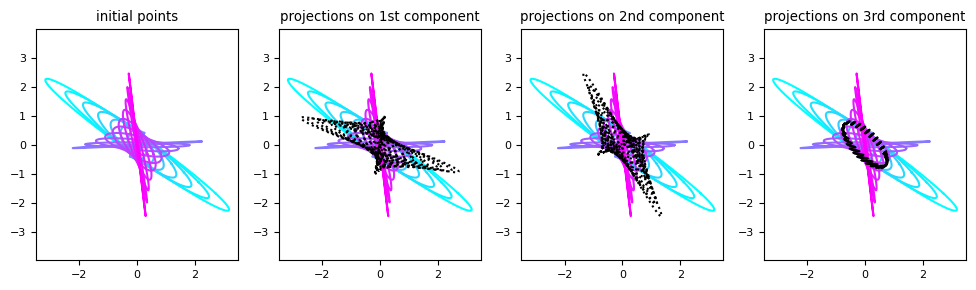

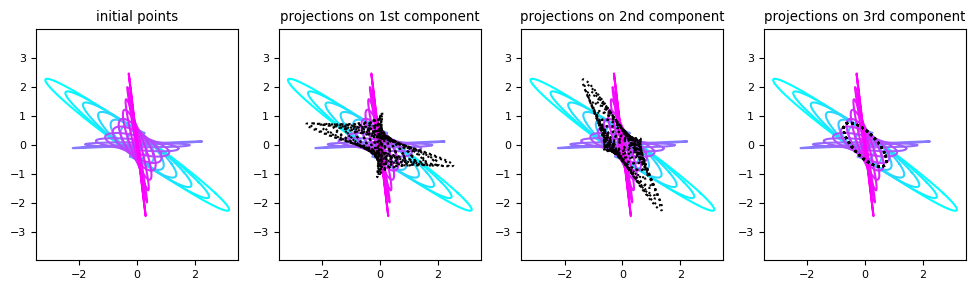

In [69]:
from tools.plot_2d import plot_results
plot_results(points_spd[i], res_gpca_list[i])
plot_results(points_spd[i], res_tpca_list[i])

In [ ]:
#import pickle
#results = {
#    'res_pga_list': res_pga_list,
#    'res_tpca_list': res_tpca_list,
#    'sec_curvature': sec_curvature,
#    'ric_curvature': ric_curvature,
#}
#pickle.dump(results, open('pga_vs_tpca_analysis-2-seed12-iter500', 'wb'))

In [ ]:
#np.save('spd_matrices_on_intersecting_geodesics_100x20', points_spd)
#points_spd_verif = np.load('spd_matrices_on_intersecting_geodesics_100x20', allow_pickle=True)
#np.sum(np.abs(points_spd - points_spd_verif))

In [ ]:
#component_1 = np.stack([res_pga_list[i]['components'][0] for i in range(n_iter)])
#print(component_1.shape)
#np.save('component_1_of_intersecting_geodesics_100x20', component_1)

In [ ]:
#from scipy.stats import norm
#from ot import sinkhorn

#def generate_gaussian_samples(n_samples, sigma):
#    cho = np.linalg.cholesky(sigma)
#    eps = np.random.normal(0., 1., (sigma.shape[-1], n_samples))
#    x = np.matmul(cho, eps).T
#    return x
#
#def compute_loss_with_samples(points_spd, component, n_samples):
#    loss = 0
#    for (pt, proj) in zip(points_spd, component):
#        samples_pt = generate_gaussian_samples(n_samples, pt)
#        samples_proj = generate_gaussian_samples(n_samples, proj)
#        sq_dist_mat = np.zeros((n_samples, n_samples))
#        for i in range(n_samples):
#            for j in range(i+1, n_samples):
#                sq_dist_mat[i, j] = np.linalg.norm(samples_proj[i] - samples_pt[j])**2
#        sq_dist_mat += sq_dist_mat.T
#        weights = np.ones(n_samples) / n_samples
#        reg = 0.05 * np.mean(np.linalg.norm(samples_pt - np.mean(samples_pt, axis=0))**2)
#        loss += sinkhorn(a=weights, b=weights, M=sq_dist_mat, reg=reg)
#    return loss    

#cost_sinkhorn = compute_loss_with_samples(points_spd[0], res_pga_list[0]['components'][0], n_samples=2**12)